# Convolutional Neural Networks Basics

## 1. Why are CNNs used for Images?

### Definition

A **Convolutional Neural Network (CNN)** is a type of neural network mainly designed for data that has spatial structure, especially images.

An image contains relationships between nearby pixels.

CNNs are designed to use these local relationships to learn useful patterns.

### My Understanding

A normal neural network can also process an image, but it may require a very large number of connections.

CNNs solve this problem by looking at small regions of an image at a time.

A CNN can learn patterns such as:

- Edges
- Corners
- Curves
- Textures
- Shapes

As the network becomes deeper, simple patterns can combine into more meaningful features.

For example:

**Edges → Shapes → Object parts → Complete object**

### Real-World Example

Suppose I see an image of a shoe.

I may first notice:

- The outline
- Curves
- Sole
- Shoe opening

Then I combine these features and recognize that the object is a shoe.

A CNN works in a similar pattern-learning process.

#### AI/ML Usage

CNNs are widely used in:

- Image classification
- Object detection
- Face recognition
- Medical image analysis
- OCR
- Manufacturing defect detection
- Satellite image analysis
- Autonomous vehicles

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


## 2. Image Dataset – Fashion-MNIST

For the practical part of this notebook, I am using the **Fashion-MNIST** dataset.

### Definition

Fashion-MNIST is an image classification dataset containing images of clothing items.

Each image is:

- 28 pixels high
- 28 pixels wide
- Grayscale
- One channel

The dataset contains 10 classes.

### Classes

1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

### Real-World Example

An online shopping company may have thousands of product images.

A machine learning model can classify these images into categories automatically.

#### AI/ML Usage

Fashion-MNIST is useful for understanding:

- Image tensors
- Image preprocessing
- CNN architecture
- Feature extraction
- Image classification

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:49<00:00, 535kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 195kB/s]
100%|██████████| 4.42M/4.42M [00:06<00:00, 632kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.13MB/s]


Training images: 60000
Testing images: 10000


In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Class:", class_names[label])

Image tensor shape: torch.Size([1, 28, 28])
Label: 9
Class: Ankle boot


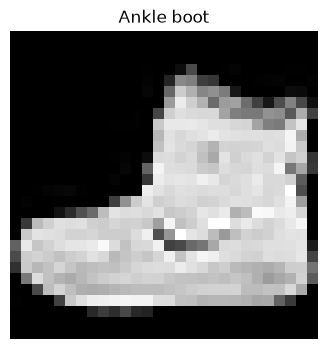

In [4]:
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off")
plt.show()

## 3. Image as a Tensor

### Definition

A **tensor** is a multi-dimensional numerical structure used to store data.

Images can be represented as tensors.

For a grayscale image:

**Channels × Height × Width**

For a color image:

**Channels × Height × Width**

For a batch of color images:

**Batch × Channels × Height × Width**

### My Understanding

A computer does not directly understand an image as we see it.

It represents the image using numbers.

Each pixel contains a numerical value.

These values are stored in a tensor.

For the Fashion-MNIST dataset:

**1 × 28 × 28**

means:

- 1 channel
- 28 pixels height
- 28 pixels width

### Real-World Example

A photograph taken using a phone can be represented using three channels:

- Red
- Green
- Blue

These three channels together represent the color image.

#### AI/ML Usage

CNN layers receive image tensors as input.

Therefore, understanding tensor dimensions is very important when implementing CNN models.

In [5]:
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())
print("Number of dimensions:", image.dim())

Image shape: torch.Size([1, 28, 28])
Image dtype: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Number of dimensions: 3


## 4. Channels

### Definition

A **channel** represents one layer of information in an image.

Common examples:

- Grayscale image → 1 channel
- RGB image → 3 channels

### My Understanding

Fashion-MNIST images are grayscale, so they have only one channel.

A normal color photograph usually has three channels:

**Red + Green + Blue**

### Real-World Example

Think of an RGB image as three transparent sheets placed on top of each other.

One sheet contains red information.

Another contains green information.

Another contains blue information.

Together they form the final color image.

#### AI/ML Usage

CNN layers need to know the number of input channels.

For example:

`nn.Conv2d(1, 8, kernel_size=3)`

means:

- Input channels = 1
- Output channels = 8
- Kernel size = 3 × 3

The 8 output channels represent 8 learned feature maps.

In [6]:
gray_example = torch.rand(1, 28, 28)
rgb_example = torch.rand(3, 28, 28)

print("Grayscale image shape:", gray_example.shape)
print("RGB image shape:", rgb_example.shape)

Grayscale image shape: torch.Size([1, 28, 28])
RGB image shape: torch.Size([3, 28, 28])


## 5. Kernel / Filter

### Definition

A **kernel**, also called a **filter**, is a small matrix that moves across an image.

The kernel contains values called weights.

It examines small regions of the image and performs calculations on them.

### My Understanding

I can think of a kernel as a small window moving across an image.

The window looks at a small portion of the image.

Then it moves to another portion.

The same process continues across the image.

Different filters can learn to detect different patterns.

### Real-World Example

Imagine using a small magnifying glass to inspect a photograph.

Instead of looking at the entire photograph at once, I inspect small areas.

A CNN filter works in a similar way.

#### AI/ML Usage

CNN filters can learn to detect:

- Edges
- Curves
- Textures
- Shapes
- Object parts

The values of these filters are learned during model training.

## 6. Convolution

### Definition

**Convolution** is the process of moving a filter across an image and performing mathematical calculations between the filter and image pixels.

For each position:

1. Select a small region of the image.
2. Multiply the image values with the filter values.
3. Add the results.
4. Store the result.
5. Move the filter.
6. Repeat the process.

### My Understanding

The filter is basically asking:

> Does this small region contain the pattern I am looking for?

The result of applying the filter across the image is called a **feature map**.

### Real-World Example

Suppose a filter has learned to detect vertical edges.

When the filter moves across the image, it produces high values in places where vertical edges are present.

#### AI/ML Usage

Convolution is the main feature extraction operation in a CNN.

Instead of manually telling the model what an edge or shape looks like, the CNN learns useful filters from training data.

## 7. Small Matrix Convolution Example

Suppose I have this image matrix:

    1  2  3
    4  5  6
    7  8  9

And this kernel:

    1  0
    0  1

For the first position, the selected region is:

    1  2
    4  5

Now multiply element by element:

    (1 × 1) + (2 × 0) + (4 × 0) + (5 × 1)

    = 1 + 0 + 0 + 5

    = 6

Therefore, the first output value is: **6**

The kernel then moves to the next position and repeats the same calculation.

### Important Idea

The complete process is:

**Image Region → Element-wise Multiplication → Addition → Output Value**

Repeating this across the image creates a feature map.

In [7]:
input_matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=float)

kernel = np.array([
    [1, 0],
    [0, 1]
], dtype=float)

region = input_matrix[0:2, 0:2]
calculation = region * kernel
value = calculation.sum()

print("Selected region:")
print(region)

print("\nKernel:")
print(kernel)

print("\nElement-wise multiplication:")
print(calculation)

print("\nConvolution value:", value)

Selected region:
[[1. 2.]
 [4. 5.]]

Kernel:
[[1. 0.]
 [0. 1.]]

Element-wise multiplication:
[[1. 0.]
 [0. 5.]]

Convolution value: 6.0


## 8. Convolution Using PyTorch

PyTorch provides convolution operations that can perform this process automatically.

This is useful because real CNNs contain many filters and operate on thousands or millions of image regions.

In [8]:
input_tensor = torch.tensor([
    [
        [1.0, 2.0, 3.0],
        [4.0, 5.0, 6.0],
        [7.0, 8.0, 9.0]
    ]
])

kernel_tensor = torch.tensor([
    [
        [1.0, 0.0],
        [0.0, 1.0]
    ]
])

conv_result = F.conv2d(
    input_tensor.unsqueeze(0),
    kernel_tensor.unsqueeze(0)
)

print("Input shape:", input_tensor.unsqueeze(0).shape)
print("Kernel shape:", kernel_tensor.unsqueeze(0).shape)
print("Convolution result:")
print(conv_result)

Input shape: torch.Size([1, 1, 3, 3])
Kernel shape: torch.Size([1, 1, 2, 2])
Convolution result:
tensor([[[[ 6.,  8.],
          [12., 14.]]]])


## 9. Feature Map

### Definition

A **feature map** is the output produced after applying a filter to an image.

It shows where the pattern detected by the filter appears.

### My Understanding

A filter looks for a particular pattern.

The feature map tells us where that pattern was found.

Different filters produce different feature maps.

### Real-World Example

Suppose one filter learns to detect edges.

Its feature map may have high values around the edges of a shirt.

Another filter may detect curves.

Its feature map may highlight curved parts of the shirt.

#### AI/ML Usage

Feature maps are intermediate representations inside CNNs.

Early layers usually learn simpler patterns.

Deeper layers can combine these patterns into more meaningful features.

In [9]:
conv_layer = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3
)

feature_maps = conv_layer(image.unsqueeze(0))

print("Input shape:", image.unsqueeze(0).shape)
print("Feature map shape:", feature_maps.shape)

Input shape: torch.Size([1, 1, 28, 28])
Feature map shape: torch.Size([1, 4, 26, 26])


## 10. Understanding the Feature Map Shape

The input image has:

**1 × 28 × 28**

The convolution layer uses:

- 1 input channel
- 4 output channels
- 3 × 3 kernel
- No padding
- Stride 1

Therefore, the output becomes:

**4 × 26 × 26**

Why?

For the spatial dimension:

**Output = ((Input + 2 × Padding − Kernel) / Stride) + 1**

Substituting the values:

**((28 + 0 − 3) / 1) + 1**

**= 26**

The output has 4 channels because the layer contains 4 filters.

Therefore:

**1 × 28 × 28 → 4 × 26 × 26**

## 11. Stride

### Definition

**Stride** tells us how many pixels the filter moves at each step.

Examples:

- Stride = 1 → move one pixel
- Stride = 2 → move two pixels

### My Understanding

Stride controls how quickly the filter moves across the image.

A larger stride means the filter skips more positions.

Therefore, a larger stride usually creates a smaller output.

### Real-World Example

Imagine scanning a large wall with a small window.

If I move the window one step at a time, I inspect many areas.

If I move it two steps at a time, I inspect fewer areas.

#### AI/ML Usage

Stride can be used to:

- Reduce image dimensions
- Reduce computation
- Control the spatial size of feature maps

In [10]:
stride_one = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3,
    stride=1
)

stride_two = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3,
    stride=2
)

output_stride_one = stride_one(image.unsqueeze(0))
output_stride_two = stride_two(image.unsqueeze(0))

print("Stride 1 shape:", output_stride_one.shape)
print("Stride 2 shape:", output_stride_two.shape)

Stride 1 shape: torch.Size([1, 4, 26, 26])
Stride 2 shape: torch.Size([1, 4, 13, 13])


## 12. Padding

### Definition

**Padding** means adding extra pixels around the border of an image before performing convolution.

Usually, zero values are added.

### Why is Padding Needed?

Without padding, the image becomes smaller after convolution.

Padding can help:

- Preserve image dimensions
- Preserve border information
- Allow filters to work near image edges

### My Understanding

Padding is like adding a border around the image.

This gives the convolution filter additional space near the edges.

### Real-World Example

Imagine putting a frame around a photograph before scanning it.

The frame gives extra space around the edges.

#### AI/ML Usage

Padding is commonly used in CNN architectures to control the output dimensions.

For a 3 × 3 kernel with stride 1, padding 1 can preserve the original height and width.

In [11]:
no_padding = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3,
    padding=0
)

same_padding = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    kernel_size=3,
    padding=1
)

output_no_padding = no_padding(image.unsqueeze(0))
output_same_padding = same_padding(image.unsqueeze(0))

print("Without padding:", output_no_padding.shape)
print("With padding:", output_same_padding.shape)

Without padding: torch.Size([1, 4, 26, 26])
With padding: torch.Size([1, 4, 28, 28])


## 13. Image Dimension Formula After Convolution

The output size of a convolution can be calculated using:

**Output Size = floor((Input Size + 2 × Padding − Kernel Size) / Stride) + 1**

### Example 1

Input:

**28 × 28**

Kernel:

**3 × 3**

Padding:

**0**

Stride:

**1**

Calculation:

**((28 + 0 − 3) / 1) + 1 = 26**

Therefore:

**28 × 28 → 26 × 26**

### Example 2

Input:

**28 × 28**

Kernel:

**3 × 3**

Padding:

**1**

Stride:

**1**

Calculation:

**((28 + 2 − 3) / 1) + 1 = 28**

Therefore:

**28 × 28 → 28 × 28**

#### AI/ML Usage

Dimension calculations are important because CNN layers must receive the expected tensor shape.

It also helps when deciding the architecture of a CNN.

## 14. Pooling

### Definition

**Pooling** is a downsampling operation that reduces the spatial dimensions of feature maps.

Common types:

- Max Pooling
- Average Pooling

### My Understanding

Pooling takes a small region of a feature map and summarizes it into one value.

This reduces the size of the feature map.

### Real-World Example

Imagine dividing a large group of people into small groups and keeping one summary value for each group.

Pooling does something similar with image features.

### Why Use Pooling?

Pooling can:

- Reduce spatial dimensions
- Reduce computation
- Reduce memory usage
- Keep important information
- Make the representation less sensitive to small changes

#### AI/ML Usage

Pooling is commonly used after convolution and activation layers in CNN architectures.

## 15. Max Pooling

### Definition

**Max pooling** selects the largest value from each small region.

Example:

    1  5
    2  3

The maximum value is:

**5**

Therefore, max pooling produces:

**5**

### My Understanding

Max pooling asks:

> What is the strongest feature in this small region?

### Real-World Example

If a filter detects an edge strongly in one part of a small region, max pooling keeps that strongest response.

#### AI/ML Usage

Max pooling is widely used to reduce feature-map size while keeping strong feature activations.

In [12]:
pool_input = torch.tensor([
    [
        [1.0, 5.0, 2.0, 4.0],
        [3.0, 2.0, 1.0, 6.0],
        [7.0, 1.0, 8.0, 2.0],
        [4.0, 3.0, 5.0, 9.0]
    ]
])

max_pool = F.max_pool2d(
    pool_input.unsqueeze(0),
    kernel_size=2,
    stride=2
)

print("Input:")
print(pool_input)

print("\nMax pooled output:")
print(max_pool.squeeze(0))

Input:
tensor([[[1., 5., 2., 4.],
         [3., 2., 1., 6.],
         [7., 1., 8., 2.],
         [4., 3., 5., 9.]]])

Max pooled output:
tensor([[[5., 6.],
         [7., 9.]]])


## 16. Max Pooling Dimension Change

Suppose the input feature map is:

**4 × 4**

We use:

- Pooling window = 2 × 2
- Stride = 2

The output becomes:

**2 × 2**

Therefore:

**4 × 4 → 2 × 2**

The pooling operation looks at four values at a time and keeps only the largest one.

This reduces the spatial dimensions by half.

## 17. Average Pooling

### Definition

**Average pooling** calculates the average value inside each pooling region.

Example:

    1  5
    2  4

Average:

**(1 + 5 + 2 + 4) / 4**

**= 3**

Therefore, the output value is:

**3**

### My Understanding

Average pooling asks:

> What is the overall feature strength in this small region?

### Real-World Example

Suppose I have the marks of four students.

Instead of selecting the highest mark, I calculate their average.

Max pooling is similar to selecting the highest value.

Average pooling is similar to calculating the group average.

#### AI/ML Usage

Average pooling provides a smoother summary of feature information.

It can be used as an alternative to max pooling.

In [13]:
avg_pool = F.avg_pool2d(
    pool_input.unsqueeze(0),
    kernel_size=2,
    stride=2
)

print("Average pooled output:")
print(avg_pool.squeeze(0))

Average pooled output:
tensor([[[2.7500, 3.2500],
         [3.7500, 6.0000]]])


## 18. Max Pooling vs Average Pooling

| Pooling Type | Operation | Simple Meaning |
|---|---|---|
| Max Pooling | Selects maximum value | Strongest feature |
| Average Pooling | Calculates average | Overall feature strength |

#### AI/ML Usage

Both methods reduce spatial dimensions.

Max pooling focuses on the strongest activation.

Average pooling keeps the average information from the region.

## 19. Flattening

### Definition

**Flattening** converts a multi-dimensional feature map into a one-dimensional vector.

For example:

**4 × 7 × 7**

becomes:

**196**

because:

**4 × 7 × 7 = 196**

### My Understanding

Convolution and pooling produce structured feature maps.

A fully connected layer needs these features in a vector form.

Flattening converts the feature maps into that vector.

### Real-World Example

Imagine having several trays containing objects.

Flattening is like taking all the objects from the trays and putting them into one long list.

#### AI/ML Usage

Flattening is commonly used to connect convolutional feature extraction with fully connected layers.

In [14]:
sample_features = torch.randn(1, 4, 7, 7)

flattened = torch.flatten(
    sample_features,
    start_dim=1
)

print("Before flattening:", sample_features.shape)
print("After flattening:", flattened.shape)

Before flattening: torch.Size([1, 4, 7, 7])
After flattening: torch.Size([1, 196])


## 20. Fully Connected Layer

### Definition

A **fully connected layer**, also called a **linear layer**, connects every input value to neurons in the next layer.

In PyTorch, it is represented using:

`nn.Linear`

### My Understanding

The convolution layers mainly extract useful features from the image.

The fully connected layer uses those extracted features to help make the final prediction.

### Real-World Example

Suppose I identify:

- Shape
- Curves
- Edges
- Texture
- Object parts

Then I combine those clues and decide:

> This image is probably a sneaker.

The convolution layers help collect the visual clues.

The fully connected layer helps use those clues for classification.

#### AI/ML Usage

Fully connected layers are often used near the end of CNN classifiers to produce class scores.

In [15]:
linear_layer = nn.Linear(196, 10)

class_scores = linear_layer(flattened)

print("Input to linear layer:", flattened.shape)
print("Output class scores:", class_scores.shape)

Input to linear layer: torch.Size([1, 196])
Output class scores: torch.Size([1, 10])


## 21. Activation Function – ReLU

### Definition

An activation function introduces non-linearity into a neural network.

One of the most commonly used activation functions in CNNs is **ReLU**.

ReLU means:

**Rectified Linear Unit**

The formula is:

**ReLU(x) = max(0, x)**

So:

- Negative values become 0
- Positive values remain positive

### My Understanding

ReLU can be thought of as a gate.

If the signal is negative, it is blocked.

If the signal is positive, it passes through.

### Real-World Example

Imagine a gate that only allows positive signals to pass.

Negative signal → blocked

Positive signal → allowed

#### AI/ML Usage

ReLU allows CNNs to learn complex non-linear patterns.

In [16]:
activation_input = torch.tensor([
    -2.0,
    -0.5,
    0.0,
    1.5,
    3.0
])

activation_output = F.relu(activation_input)

print("Before ReLU:", activation_input)
print("After ReLU:", activation_output)

Before ReLU: tensor([-2.0000, -0.5000,  0.0000,  1.5000,  3.0000])
After ReLU: tensor([0.0000, 0.0000, 0.0000, 1.5000, 3.0000])


## 22. CNN Architecture

The basic CNN architecture I need to remember is:

**Image → Convolution → Activation → Pooling → Convolution → Pooling → Flatten → Fully Connected → Output**

### Step-by-Step

### 1. Image

The original image enters the CNN as a tensor.

### 2. Convolution

Filters scan the image and detect local patterns.

### 3. Activation

ReLU adds non-linearity.

### 4. Pooling

Pooling reduces the spatial dimensions.

### 5. Second Convolution

The network extracts more complex features.

### 6. Second Pooling

The spatial dimensions are reduced again.

### 7. Flatten

Feature maps are converted into a vector.

### 8. Fully Connected Layer

The extracted features are used for classification.

### 9. Output

The model produces scores for the possible classes.

## Main Idea

The CNN gradually transforms:

**Pixels → Simple Features → Complex Features → Classification**

## 23. Build a Simple CNN

Now I will create a simple CNN using Fashion-MNIST.

The model contains:

- First convolution
- ReLU
- Max pooling
- Second convolution
- ReLU
- Max pooling
- Flattening
- Fully connected layer
- Output

I am keeping the model simple so that I can understand how data flows through each layer.

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            padding=1
        )
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            padding=1
        )
        self.fc1 = nn.Linear(
            16 * 7 * 7,
            10
        )

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        return x

model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


## 24. Understanding the CNN Dimensions

The input image is:

**1 × 28 × 28**

### First Convolution

The first convolution creates 8 feature maps.

Padding = 1 keeps the spatial size unchanged.

Therefore:

**1 × 28 × 28 → 8 × 28 × 28**

### First Max Pooling

Using a 2 × 2 pooling window with stride 2:

**8 × 28 × 28 → 8 × 14 × 14**

### Second Convolution

The second convolution creates 16 feature maps.

Padding = 1 keeps the spatial dimensions.

Therefore:

**8 × 14 × 14 → 16 × 14 × 14**

### Second Max Pooling

The 2 × 2 pooling reduces the spatial dimensions again.

Therefore:

**16 × 14 × 14 → 16 × 7 × 7**

### Flatten

Now:

**16 × 7 × 7 = 784**

Therefore:

**16 × 7 × 7 → 784**

### Fully Connected Layer

The 784 features are converted into 10 class scores.

Therefore:

**784 → 10**

### Complete Shape Flow

**1 × 28 × 28**

↓

**8 × 28 × 28**

↓

**8 × 14 × 14**

↓

**16 × 14 × 14**

↓

**16 × 7 × 7**

↓

**784**

↓

**10**

In [19]:
sample_batch = image.unsqueeze(0).to(device)

x = model.conv1(sample_batch)
print("After convolution 1:", x.shape)

x = F.relu(x)
print("After ReLU 1:", x.shape)

x = model.pool(x)
print("After pooling 1:", x.shape)

x = model.conv2(x)
print("After convolution 2:", x.shape)

x = F.relu(x)
print("After ReLU 2:", x.shape)

x = model.pool(x)
print("After pooling 2:", x.shape)

x = torch.flatten(x, start_dim=1)
print("After flattening:", x.shape)

x = model.fc1(x)
print("Final output:", x.shape)

After convolution 1: torch.Size([1, 8, 28, 28])
After ReLU 1: torch.Size([1, 8, 28, 28])
After pooling 1: torch.Size([1, 8, 14, 14])
After convolution 2: torch.Size([1, 16, 14, 14])
After ReLU 2: torch.Size([1, 16, 14, 14])
After pooling 2: torch.Size([1, 16, 7, 7])
After flattening: torch.Size([1, 784])
Final output: torch.Size([1, 10])


## 25. Why Do Image Dimensions Become Smaller?

Two important operations can change the spatial dimensions:

### Convolution

Without padding, convolution usually reduces the height and width.

Example:

**28 × 28 → 26 × 26**

when using:

- Kernel = 3
- Padding = 0
- Stride = 1

### Pooling

Pooling intentionally reduces spatial dimensions.

Example:

**28 × 28 → 14 × 14**

using:

- Pool size = 2 × 2
- Stride = 2

### Why Reduce Dimensions?

Reducing dimensions can:

- Reduce computation
- Reduce memory usage
- Make later processing easier
- Keep important features
- Reduce the amount of spatial information passed to later layers

### Important Point

CNNs do not simply make an image smaller.

The CNN first converts the image into **feature maps**.

Pooling then reduces the spatial size of those feature maps.

## 26. DataLoader

### Definition

A `DataLoader` provides data to a neural network in batches.

### My Understanding

Instead of sending the entire dataset into the model at once, I can send smaller groups of images.

For example:

**64 images → one batch**

Then another 64 images are processed.

### Real-World Example

A warehouse may process products in batches rather than trying to process everything at the same time.

#### AI/ML Usage

Batch processing:

- Makes training practical
- Reduces memory requirements
- Works well with GPU computation
- Helps organize the training process

## 26. DataLoader

### Definition

A `DataLoader` provides data to a neural network in batches.

### My Understanding

Instead of sending the entire dataset into the model at once, I can send smaller groups of images.

For example:

**64 images → one batch**

Then another 64 images are processed.

### Real-World Example

A warehouse may process products in batches rather than trying to process everything at the same time.

#### AI/ML Usage

Batch processing:

- Makes training practical
- Reduces memory requirements
- Works well with GPU computation
- Helps organize the training process

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


## 27. Understanding the Batch Shape

The batch shape should be:

**64 × 1 × 28 × 28**

This means:

- 64 → number of images in the batch
- 1 → channel
- 28 → height
- 28 → width

The general format used by PyTorch CNNs is:

**Batch × Channels × Height × Width**

This is an important format to remember when working with CNNs in PyTorch.

## 28. Passing a Batch Through the CNN

Now I will pass one batch of Fashion-MNIST images through the CNN.

The model has not been trained yet.

Therefore, the predictions will not be expected to be accurate.

The purpose here is to understand the **forward propagation and tensor dimensions**.

In [22]:
batch_images = images.to(device)

with torch.no_grad():
    predictions = model(batch_images)

print("Input batch:", batch_images.shape)
print("Model output:", predictions.shape)

Input batch: torch.Size([64, 1, 28, 28])
Model output: torch.Size([64, 10])


## 29. Understanding the Output

The output shape should be:

**64 × 10**

This means:

- 64 images
- 10 scores for each image

There are 10 Fashion-MNIST classes.

Therefore, each image receives 10 output scores.

For example:

**Image 1 → 10 scores**

The class with the highest score can be selected as the predicted class.

Since the model has not been trained, the predictions are currently random or unreliable.

After training, the model learns useful filter weights and classification weights.

In [23]:
predicted_classes = predictions.argmax(dim=1)

print("First 10 predicted class indexes:")
print(predicted_classes[:10])

print("\nFirst 10 actual class indexes:")
print(labels[:10])

First 10 predicted class indexes:
tensor([9, 7, 8, 7, 8, 8, 7, 8, 8, 8])

First 10 actual class indexes:
tensor([9, 4, 3, 7, 3, 1, 2, 1, 1, 0])
